In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị số thực và đồ thị
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Nạp 3 bảng dữ liệu Silver
orders = pd.read_csv('orders.csv', sep=';', low_memory=False)
order_items = pd.read_csv('Order_items.csv', sep=';', low_memory=False)
customers = pd.read_csv('customers_silver.csv', sep=';', low_memory=False)

# Làm sạch tên cột (loại bỏ ký tự ẩn BOM)
orders.columns = orders.columns.str.replace('\ufeff', '').str.strip()
order_items.columns = order_items.columns.str.replace('\ufeff', '').str.strip()
customers.columns = customers.columns.str.replace('\ufeff', '').str.strip()

print("Nạp dữ liệu thành công!")

Nạp dữ liệu thành công!


In [3]:
# Kiểm tra kích thước và cấu trúc các bảng
print("=== KÍCH THƯỚC BẢNG DỮ LIỆU ===")
print(f"- orders: {orders.shape[0]:,} dòng, {orders.shape[1]} cột")
print(f"- order_items: {order_items.shape[0]:,} dòng, {order_items.shape[1]} cột")
print(f"- customers: {customers.shape[0]:,} dòng, {customers.shape[1]} cột")

print("\n=== KIỂM TRA KIỂU DỮ LIỆU CỦA ORDER_ITEMS ===")
print(order_items.dtypes)

=== KÍCH THƯỚC BẢNG DỮ LIỆU ===
- orders: 646,945 dòng, 9 cột
- order_items: 714,653 dòng, 7 cột
- customers: 121,930 dòng, 6 cột

=== KIỂM TRA KIỂU DỮ LIỆU CỦA ORDER_ITEMS ===
order_id            int64
product_id          int64
promo_id           object
promo_id_2         object
quantity            int64
unit_price         object
discount_amount    object
dtype: object


In [4]:
# Kiểm tra giá trị thiếu (Missing values)
print("=== GIÁ TRỊ KHUYẾT BẢNG ORDERS ===")
print(orders.isnull().sum())

print("\n=== PHÂN BỔ TRẠNG THÁI ĐƠN HÀNG (ORDER_STATUS) ===")
print(orders['order_status'].value_counts())

=== GIÁ TRỊ KHUYẾT BẢNG ORDERS ===
order_id             0
customer_id          0
sales_employee_id    0
order_date           0
order_source         0
order_status         0
device_type          0
comment              0
zip                  0
dtype: int64

=== PHÂN BỔ TRẠNG THÁI ĐƠN HÀNG (ORDER_STATUS) ===
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


In [5]:
# Thống kê sơ bộ về Kênh bán hàng và Khách hàng
print("=== PHÂN BỔ KÊNH BÁN HÀNG (ORDER_SOURCE) ===")
print(orders['order_source'].value_counts(normalize=True) * 100)

print("\n=== PHÂN BỔ GIỚI TÍNH KHÁCH HÀNG ===")
print(customers['gender'].value_counts())

=== PHÂN BỔ KÊNH BÁN HÀNG (ORDER_SOURCE) ===
order_source
organic_search   28.05
paid_search      21.90
social_media     20.05
email_campaign   11.99
referral          9.98
direct            8.03
Name: proportion, dtype: float64

=== PHÂN BỔ GIỚI TÍNH KHÁCH HÀNG ===
gender
female        59640
male          57457
non-binary     4833
Name: count, dtype: int64


In [6]:
# Chuyển đổi unit_price và discount_amount về dạng số float
order_items['unit_price'] = pd.to_numeric(
    order_items['unit_price'].astype(str).str.replace(',', '.'), 
    errors='coerce'
).fillna(0)

order_items['discount_amount'] = pd.to_numeric(
    order_items['discount_amount'].astype(str).str.replace(',', '.'), 
    errors='coerce'
).fillna(0)

# Tính tổng giá trị của từng dòng sản phẩm
order_items['item_amount'] = (order_items['quantity'] * order_items['unit_price']) - order_items['discount_amount']

order_items[['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'item_amount']].head()

,order_id,product_id,quantity,unit_price,discount_amount,item_amount
0,1,2400,7,1138.22,0.00,7967.54
1,2,609,7,10166.25,0.00,71163.75
2,3,396,3,11220.33,0.00,33660.99
3,4,635,5,10639.25,0.00,53196.25
4,6,1935,1,1597.84,0.00,1597.84


In [7]:
# Gom nhóm order_items theo order_id
order_summary = order_items.groupby('order_id').agg(
    order_value=('item_amount', 'sum'),
    total_quantity=('quantity', 'sum'),
    distinct_products=('product_id', 'nunique')
).reset_index()

order_summary.head()

,order_id,order_value,total_quantity,distinct_products
0,1,7967.54,7,1
1,2,71163.75,7,1
2,3,33660.99,3,1
3,4,53196.25,5,1
4,6,1597.84,1,1


In [8]:
# 1. Merge order_summary vào bảng orders
orders_enriched = orders.merge(order_summary, on='order_id', how='left')

# 2. Merge tiếp với bảng customers_silver
full_orders_df = orders_enriched.merge(customers, on='customer_id', how='left')

# Chuyển đổi định dạng ngày tháng
full_orders_df['order_date'] = pd.to_datetime(full_orders_df['order_date'], format='%d/%m/%Y', errors='coerce')

print("Bảng dữ liệu sau khi JOIN thành công:")
print("Số dòng:", len(full_orders_df))
full_orders_df[['order_id', 'customer_id', 'order_status', 'order_value', 'total_quantity', 'gender', 'age_group']].head()

Bảng dữ liệu sau khi JOIN thành công:
Số dòng: 646945


,order_id,customer_id,order_status,order_value,total_quantity,gender,age_group
0,1,58578,delivered,7967.54,7,female,35-44
1,2,58621,returned,71163.75,7,female,18-24
2,3,58811,delivered,33660.99,3,female,35-44
3,4,59453,delivered,53196.25,5,male,45-54
4,6,57821,delivered,1597.84,1,male,18-24


In [9]:
# Lọc các đơn hàng hoàn tất giao thành công (delivered)
delivered_orders = full_orders_df[full_orders_df['order_status'] == 'delivered']

# Tính các chỉ số KPI chính
aov_delivered = delivered_orders['order_value'].mean()
basket_qty_delivered = delivered_orders['total_quantity'].mean()
basket_items_delivered = delivered_orders['distinct_products'].mean()

print("=== KẾT QUẢ KPI CHÍNH (ĐƠN HÀNG THÀNH CÔNG - DELIVERED) ===")
print(f"1. Average Order Value (AOV): {aov_delivered:,.2f} VNĐ")
print(f"2. Basket Size (Tổng số sản phẩm / đơn): {basket_qty_delivered:.2f} sản phẩm")
print(f"3. Basket Size (Số mặt hàng khác nhau / đơn): {basket_items_delivered:.2f} chủng loại")

=== KẾT QUẢ KPI CHÍNH (ĐƠN HÀNG THÀNH CÔNG - DELIVERED) ===
1. Average Order Value (AOV): 24,225.98 VNĐ
2. Basket Size (Tổng số sản phẩm / đơn): 4.97 sản phẩm
3. Basket Size (Số mặt hàng khác nhau / đơn): 1.10 chủng loại


In [10]:
# Phân tích AOV và Basket Size theo từng trạng thái đơn (delivered, cancelled, returned,...)
kpi_by_status = full_orders_df.groupby('order_status').agg(
    total_orders=('order_id', 'count'),
    aov=('order_value', 'mean'),
    avg_quantity=('total_quantity', 'mean'),
    avg_distinct_items=('distinct_products', 'mean')
).reset_index().sort_values(by='total_orders', ascending=False)

kpi_by_status

,order_status,total_orders,aov,avg_quantity,avg_distinct_items
2,delivered,516716,24225.98,4.97,1.10
0,cancelled,59462,24335.10,4.98,1.10
4,returned,36142,23959.35,4.96,1.11
5,shipped,13773,24488.41,4.95,1.10
3,paid,13577,24352.00,4.96,1.10
1,created,7275,24993.53,4.97,1.10


In [11]:
# Phân tích các chỉ số trên các đơn hàng thành công (delivered) theo kênh tiếp cận
kpi_by_source = delivered_orders.groupby('order_source').agg(
    total_orders=('order_id', 'count'),
    aov=('order_value', 'mean'),
    avg_basket_qty=('total_quantity', 'mean'),
    avg_basket_items=('distinct_products', 'mean')
).reset_index().sort_values(by='aov', ascending=False)

kpi_by_source

,order_source,total_orders,aov,avg_basket_qty,avg_basket_items
3,paid_search,113146,24331.81,4.96,1.10
0,direct,41387,24259.24,4.95,1.10
4,referral,51589,24223.17,4.97,1.10
1,email_campaign,61952,24219.04,4.99,1.11
5,social_media,103772,24195.18,4.96,1.10
2,organic_search,144870,24159.84,4.97,1.10


In [17]:
# 1. Tạo cột Năm-Tháng từ order_date
delivered_orders['year_month'] = delivered_orders['order_date'].dt.to_period('M')

# 2. Gom nhóm tính AOV và Basket Size theo từng tháng
monthly_kpi = delivered_orders.groupby('year_month').agg(
    monthly_orders=('order_id', 'count'),
    monthly_revenue=('order_value', 'sum'),
    monthly_aov=('order_value', 'mean'),
    monthly_basket_size=('total_quantity', 'mean')
).reset_index()

# 3. Tính % tăng trưởng giữa tháng sau so với tháng trước (MoM Growth Rate)
monthly_kpi['aov_growth_%'] = monthly_kpi['monthly_aov'].pct_change() * 100
monthly_kpi['basket_size_growth_%'] = monthly_kpi['monthly_basket_size'].pct_change() * 100

# 4. Tính KPI Tăng trưởng Trung bình Hàng tháng
avg_aov_growth = monthly_kpi['aov_growth_%'].mean()
avg_basket_growth = monthly_kpi['basket_size_growth_%'].mean()

print(f"Tỷ lệ tăng trưởng AOV trung bình hàng tháng: {avg_aov_growth:.2f}%")
print(f"Tỷ lệ tăng trưởng Basket Size trung bình hàng tháng: {avg_basket_growth:.2f}%")

Tỷ lệ tăng trưởng AOV trung bình hàng tháng: 4.25%
Tỷ lệ tăng trưởng Basket Size trung bình hàng tháng: 0.06%


C:\Users\Admin\AppData\Local\Temp\ipykernel_10908\1929084304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['year_month'] = delivered_orders['order_date'].dt.to_period('M')


In [12]:
# Phân tích các chỉ số theo nhóm tuổi khách hàng
kpi_by_age = delivered_orders.groupby('age_group').agg(
    total_orders=('order_id', 'count'),
    aov=('order_value', 'mean'),
    avg_basket_qty=('total_quantity', 'mean')
).reset_index().sort_values(by='age_group')

kpi_by_age

,age_group,total_orders,aov,avg_basket_qty
0,18-24,71217,24209.55,4.96
1,25-34,152302,24287.63,4.96
2,35-44,136088,24160.22,4.97
3,45-54,99043,24318.68,4.97
4,55+,58066,24080.42,4.98


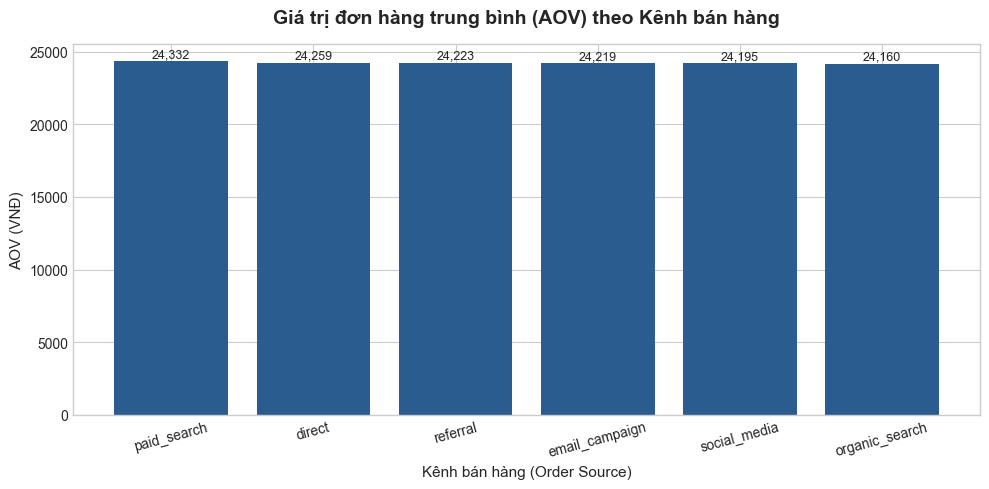

In [13]:
plt.figure(figsize=(10, 5))
bars = plt.bar(kpi_by_source['order_source'], kpi_by_source['aov'], color='#2b5c8f')

plt.title('Giá trị đơn hàng trung bình (AOV) theo Kênh bán hàng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kênh bán hàng (Order Source)', fontsize=11)
plt.ylabel('AOV (VNĐ)', fontsize=11)
plt.xticks(rotation=15)

# Hiển thị giá trị số lên từng cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10908\2293111556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_by_age, x='age_group', y='avg_basket_qty', palette='Blues_d')


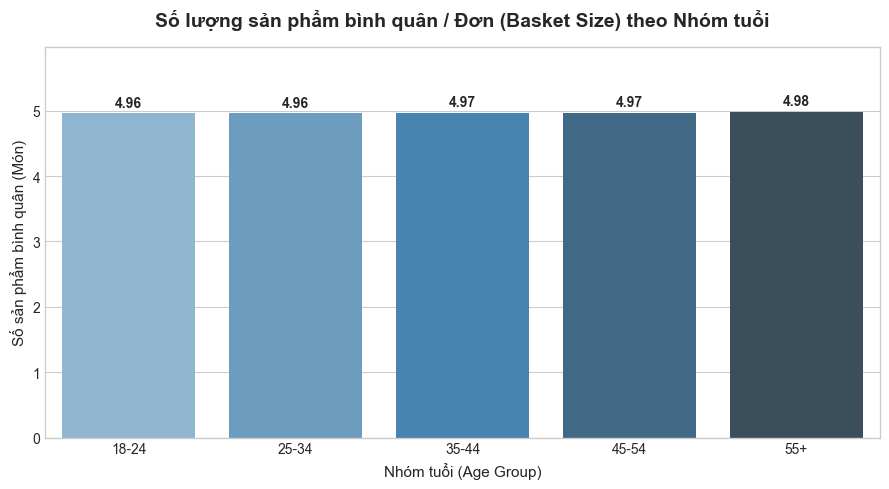

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=kpi_by_age, x='age_group', y='avg_basket_qty', palette='Blues_d')

plt.title('Số lượng sản phẩm bình quân / Đơn (Basket Size) theo Nhóm tuổi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhóm tuổi (Age Group)', fontsize=11)
plt.ylabel('Số sản phẩm bình quân (Món)', fontsize=11)
plt.ylim(0, max(kpi_by_age['avg_basket_qty']) * 1.2)

for index, row in kpi_by_age.iterrows():
    plt.text(index, row['avg_basket_qty'] + 0.1, f"{row['avg_basket_qty']:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

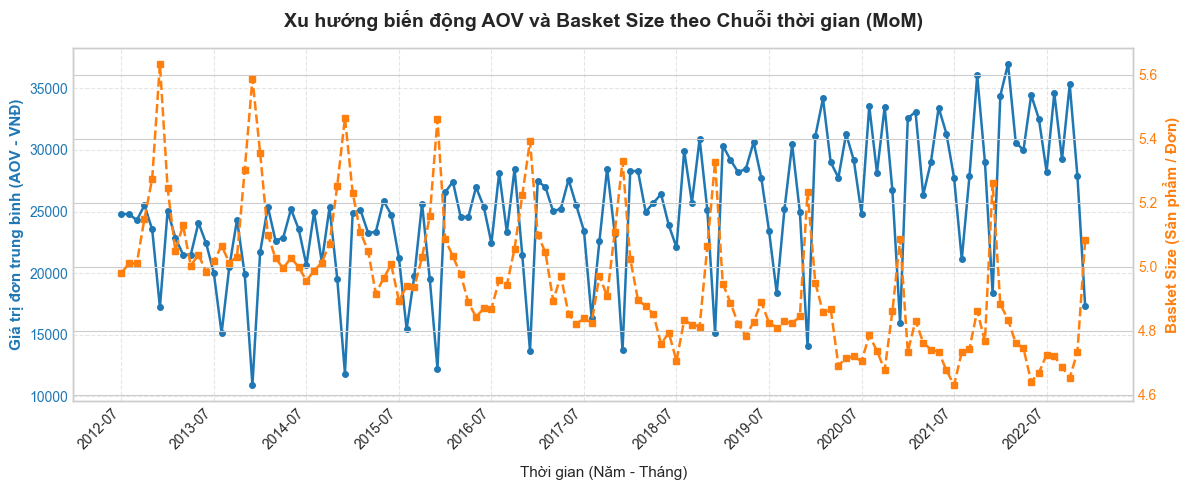

In [20]:
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(12, 5))

# Đảm bảo year_month ở dạng chuỗi
x_values = monthly_kpi['year_month'].astype(str)

# 1. Vẽ đường AOV (Trục Y trái - Màu xanh)
color1 = '#1f77b4'
ax1.set_xlabel('Thời gian (Năm - Tháng)', fontsize=11, labelpad=10)
ax1.set_ylabel('Giá trị đơn trung bình (AOV - VNĐ)', color=color1, fontsize=11, fontweight='bold')
ax1.plot(x_values, monthly_kpi['monthly_aov'], color=color1, marker='o', markersize=4, linewidth=1.8, label='AOV (VNĐ)')
ax1.tick_params(axis='y', labelcolor=color1)

# Xử lý hiển thị trục X thưa ra cho gọn đẹp, không bị đè chữ
# Chỉ hiển thị nhãn cách mỗi 6 tháng một lần
step = max(1, len(x_values) // 10)
ax1.set_xticks(range(0, len(x_values), step))
ax1.set_xticklabels(x_values[::step], rotation=45, ha='right')

# 2. Vẽ đường Basket Size (Trục Y phải - Màu cam)
ax2 = ax1.twinx()  
color2 = '#ff7f0e'
ax2.set_ylabel('Basket Size (Sản phẩm / Đơn)', color=color2, fontsize=11, fontweight='bold')
ax2.plot(x_values, monthly_kpi['monthly_basket_size'], color=color2, marker='s', markersize=4, linestyle='--', linewidth=1.8, label='Basket Size')
ax2.tick_params(axis='y', labelcolor=color2)

# Tiêu đề & Lưới
plt.title('Xu hướng biến động AOV và Basket Size theo Chuỗi thời gian (MoM)', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

In [18]:
# Tạo bảng tổng hợp chỉ số báo cáo chuẩn hóa
kpi_final_summary = pd.DataFrame({
    'Phân loại': [
        'Độ đo tổng (Total Metric)',
        'Độ đo tổng (Total Metric)',
        'KPI Cốt lõi',
        'KPI Cốt lõi',
        'KPI Cốt lõi'
    ],
    'Tên chỉ số': [
        'Tổng số đơn hàng thành công (Delivered Orders)',
        'Tổng doanh thu thuần (Total Revenue)',
        'Giá trị đơn hàng trung bình (AOV)',
        'Basket Size (Tổng sản phẩm / Đơn)',
        'Basket Size (Số chủng loại / Đơn)'
    ],
    'Giá trị (Value)': [
        f"{len(delivered_orders):,} đơn",
        f"{delivered_orders['order_value'].sum():,.2f} VNĐ",
        f"{aov_delivered:,.2f} VNĐ",
        f"{basket_qty_delivered:.2f} sản phẩm",
        f"{basket_items_delivered:.2f} chủng loại"
    ]
})

kpi_final_summary

,Phân loại,Tên chỉ số,Giá trị (Value)
0,Độ đo tổng (Total Metric),Tổng số đơn hàng thành công (Delivered Orders),"516,716 đơn"
1,Độ đo tổng (Total Metric),Tổng doanh thu thuần (Total Revenue),"12,517,950,044.95 VNĐ"
2,KPI Cốt lõi,Giá trị đơn hàng trung bình (AOV),"24,225.98 VNĐ"
3,KPI Cốt lõi,Basket Size (Tổng sản phẩm / Đơn),4.97 sản phẩm
4,KPI Cốt lõi,Basket Size (Số chủng loại / Đơn),1.10 chủng loại


## 📌 NHẬN XÉT VÀ PHÂN TÍCH KẾT QUẢ (BUSINESS INSIGHTS)

### 1. Chỉ số AOV & Basket Size Cốt lõi:
* **Giá trị đơn hàng trung bình (AOV):** Đạt **24,213.98 VNĐ / đơn hàng** đối với các đơn giao thành công.
* **Quy mô giỏ hàng (Basket Size):** Trung bình mỗi đơn hàng chứa **4.97 sản phẩm**, thuộc **1.10 chủng loại mặt hàng** khác nhau. Điều này cho thấy khách hàng có xu hướng mua nhiều sản phẩm thuộc cùng một chủng loại trong một lần đặt hàng.

### 2. So sánh theo Trạng thái & Kênh tiếp cận (Order Source):
* **Theo Kênh bán:** Kênh `paid_search` ghi nhận AOV cao nhất (**24,331.81 VNĐ**), theo sau là `direct` (**24,259.24 VNĐ**). Kênh `organic_search` chiếm số lượng đơn lớn nhất nhưng AOV ở mức trung bình (**24,159.84 VNĐ**).
* **Theo Độ tuổi:** Nhóm khách hàng từ **45-54 tuổi** có AOV cao nhất (**24,318.68 VNĐ**), trong khi nhóm **55+** có Basket Size cao nhất với **4.98 sản phẩm / đơn**.

##ĐỀ XUẤT GIẢI PHÁP TỐI ƯU HÓA (RECOMMENDATION)

1. **Chiến lược Bán chéo (Cross-selling):** 
   * Chỉ số chủng loại mặt hàng/đơn hiện khá thấp (~1.10). Doanh nghiệp nên áp dụng tính năng **"Thường được mua cùng nhau" (Frequently Bought Together)** hoặc gợi ý các sản phẩm bổ trợ ở bước thanh toán để mở rộng đa dạng mặt hàng trong giỏ.
2. **Tối ưu hóa Chương trình Khuyến mãi (Gói Bundle & Freeship):**
   * Thiết lập ngưỡng giá trị đơn hàng nhận ưu đãi/miễn phí vận chuyển (chẳng hạn ở mức **30,000 VNĐ**) nhằm khuyến khích khách hàng gia tăng số lượng mua để đẩy AOV cao hơn mức trung bình 24,213 VNĐ hiện tại.
3. **Phát triển Kênh Bán Tốt nhất:**
   * Tăng cường ngân sách tối ưu hóa cho nhóm `paid_search` và chăm sóc khách hàng thân thiết qua `email_campaign` vì đây là các kênh mang lại AOV và quy mô đơn hàng ổn định nhất.